# YOLOv11-Seg — BUSI Lezyon Segmentasyonu (Colab)

Ucuncu mimari. RTMDet-Ins ile **birebir ayni anotasyonu** goruyor: etiketler
`rt_seg_yolo_donusum.py` ile ayni COCO JSON'dan turetildi (geri-rasterize Dice 1.0,
yani normalize etme kayipsiz).

| Ortak | Nerede |
|---|---|
| Anotasyon | `veri/yolo/labels/` <- `veri/coco/busi_*.json` |
| Letterbox | Ultralytics varsayilani (`rect=False`) — RTMDet ile ayni yaklasim |
| Dice protokolu | `ortak/degerlendirme.py` |
| Sabit degerlendirme vakalari | `ortak/eval_cases.json` |

**Augmentasyon paritesi** (asagida ayri bolum): Ultralytics'in Albumentations
sarmalayicisi maskeleri tasimadigi icin geometrik donusumler Ultralytics'in kendi
parametrelerinden, fotometrikler albumentations'tan geliyor. Mosaic/MixUp kapali —
RTMDet'te de bilerek kapatilmisti.

In [15]:
!pip -q install ultralytics albumentations openpyxl

In [16]:
from google.colab import drive
drive.mount('/content/drive')

import json, os, shutil, sys, time
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

DEVICE = 0 if torch.cuda.is_available() else 'cpu'
print('Device:', torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'cpu')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Device: Tesla T4


## CONFIG

In [17]:
TOHUM = 44                   # Faz 2: 42 / 43 / 44 ile uc kosu
AGIRLIK = 'yolo11n-seg.pt'   # 2.9 M param. RTMDet-Ins-tiny 5.6 M, SegFormer-B0 3.8 M
                             # -> ucu de ayni "nano/tiny" bandinda, real-time hedefe uygun

GIRDI = 256
BATCH = 16
# MODEL_KEY girdiden turetiliyor: 384 ablasyonu ana kosuyu ezmesin
MODEL_KEY = f'yolo11n_seg_{GIRDI}_orta_s{TOHUM}'
MAX_EPOCH = 100              # 70 denendi ve geri alindi: MAX_EPOCH'u kisaltmak cosine
                             # takvimini yeniden olcekliyor, RTMDet'te zirve ep28'e dustu
RESUME = False

PROJE = '/content/drive/MyDrive/real_time_segmentasyon'
VERI_KAYNAK = f'{PROJE}/Dataset_BUSI_with_GT'
VERI = '/content/dataset'
YOLO_VERI = '/content/yolo_veri'             # images/ + labels/ agaci burada kuruluyor

DRIVE_DIR = f'{PROJE}/{MODEL_KEY}'
LOCAL_DIR = f'/content/outputs/{MODEL_KEY}'
CASES_DIR = f'{DRIVE_DIR}/{MODEL_KEY}_cases'
for d in [DRIVE_DIR, LOCAL_DIR, CASES_DIR]:
    Path(d).mkdir(parents=True, exist_ok=True)

EXCEL_LOG = f'{DRIVE_DIR}/{MODEL_KEY}_log.xlsx'
CURVES_PNG = f'{DRIVE_DIR}/{MODEL_KEY}_curves.png'
VAL_ESIK_XLSX = f'{DRIVE_DIR}/{MODEL_KEY}_val_esik.xlsx'
TEST_XLSX = f'{DRIVE_DIR}/{MODEL_KEY}_test_summary.xlsx'

sys.path.insert(0, f'{PROJE}/ortak')
os.environ['RT_SEG_KOK'] = PROJE
os.environ['RT_SEG_VERI'] = VERI

print('MODEL_KEY:', MODEL_KEY, '| girdi', GIRDI, '| batch', BATCH, '| epoch', MAX_EPOCH)


def mirror_to_local(drive_path):
    dst = Path(LOCAL_DIR) / Path(drive_path).name
    shutil.copy2(drive_path, dst)
    return str(dst)

MODEL_KEY: yolo11n_seg_256_orta_s44 | girdi 256 | batch 16 | epoch 100


## On kosul: Colab makinesinde olmasi gereken dosyalar

VSCode'dan calisilsa bile **kernel Colab makinesinde**, dolayisiyla kodun okudugu
her sey Drive'da olmali. Notebook dosyasinin kendisi yerelde durabilir.

Eksik varsa `colab_yukle.zip` Drive'daki proje klasorune birakilir; asagidaki hucre
onu **yalnizca eksik dosyalar icin** acar, Drive'da zaten var olani ezmez.

In [18]:
import importlib
import zipfile

GEREKLI = [
    'ortak/degerlendirme.py', 'ortak/eval_cases.json',
    'veri/veri_manifest.csv', 'veri/yolo/dosya_haritasi.csv',
    'veri/yolo/labels/train', 'veri/yolo/labels/val', 'veri/yolo/labels/test',
]

eksik = [g for g in GEREKLI if not Path(f'{PROJE}/{g}').exists()]
if eksik:
    paket = Path(f'{PROJE}/colab_yukle.zip')
    if paket.exists():
        with zipfile.ZipFile(paket) as z:
            acilan = [a for a in z.namelist()
                      if not a.endswith('/') and not Path(f'{PROJE}/{a}').exists()]
            z.extractall(PROJE, members=acilan)
        print(f'{paket.name}: {len(acilan)} dosya acildi')
        eksik = [g for g in GEREKLI if not Path(f'{PROJE}/{g}').exists()]

if eksik:
    raise FileNotFoundError(
        'Drive\'da eksik dosyalar:\n  ' + '\n  '.join(eksik) +
        f'\n\nCozum: colab_yukle.zip dosyasini {PROJE}/ icine yukleyip bu hucreyi'
        ' tekrar calistirin (yerelde d:/mamografi/colab_yukle.zip).')

# Dosyalar calisma aninda olustugu icin sart: sys.path'e eklenen bir dizin
# modul bulunamadan taranmissa Python sonucu path_importer_cache'e yaziyor ve
# klasor sonradan dolsa bile yeniden bakmiyor.
importlib.invalidate_caches()

print('on kosullar tamam')
for g in GEREKLI:
    print('  ', g)

on kosullar tamam
   ortak/degerlendirme.py
   ortak/eval_cases.json
   veri/veri_manifest.csv
   veri/yolo/dosya_haritasi.csv
   veri/yolo/labels/train
   veri/yolo/labels/val
   veri/yolo/labels/test


## Veri agaci

Ultralytics etiket yolunu goruntu yolundaki `/images/` -> `/labels/` degisimiyle
buluyor, dolayisiyla agac o sekilde kurulmali. Goruntuler Drive'da ikilenmiyor:
`dosya_haritasi.csv` hangi kaynagin hangi `stem`'e karsilik geldigini tutuyor.

In [19]:
if not Path(VERI).exists():
    t0 = time.time()
    shutil.copytree(VERI_KAYNAK, VERI)
    print(f'veri kopyalandi: {time.time() - t0:.0f} sn')

harita = pd.read_csv(f'{PROJE}/veri/yolo/dosya_haritasi.csv')

for split in ['train', 'val', 'test']:
    (Path(YOLO_VERI) / 'images' / split).mkdir(parents=True, exist_ok=True)
    hedef = Path(YOLO_VERI) / 'labels' / split
    if hedef.exists():
        shutil.rmtree(hedef)
    shutil.copytree(f'{PROJE}/veri/yolo/labels/{split}', hedef)

for r in harita.itertuples():
    hedef = Path(YOLO_VERI) / 'images' / r.split / f'{r.stem}.png'
    if not hedef.exists():
        shutil.copy2(Path(VERI) / r.kaynak, hedef)

DATA_YAML = f'{YOLO_VERI}/data.yaml'
Path(DATA_YAML).write_text(
    f'path: {YOLO_VERI}\ntrain: images/train\nval: images/val\ntest: images/test\n'
    'names:\n  0: lezyon\n', encoding='utf-8')

for split in ['train', 'val', 'test']:
    ni = len(list((Path(YOLO_VERI) / 'images' / split).glob('*.png')))
    nl = len(list((Path(YOLO_VERI) / 'labels' / split).glob('*.txt')))
    print(f'{split}: {ni} goruntu / {nl} etiket')
    assert ni == nl == int((harita.split == split).sum()), f'{split} agaci eksik'

train: 538 goruntu / 538 etiket
val: 116 goruntu / 116 etiket
test: 115 goruntu / 115 etiket


## Augmentasyon paritesi

Ultralytics'in `Albumentations` sarmalayicisi `image` + `bboxes` gonderiyor, maske
gondermiyor — geometrik bir albumentations donusumu enjekte etmek etiketleri sessizce
bozardi. Bu yuzden:

| RTMDet (`orta` zincir) | YOLO karsiligi |
|---|---|
| `HorizontalFlip p=0.5` | `fliplr=0.5` |
| `Affine` ±15° / ±%15 olcek / ±%10 kaydirma, p=0.7 | `degrees=15, scale=0.15, translate=0.1` |
| `RandomBrightnessContrast ±0.2 p=0.5` | albumentations enjeksiyonu |
| `RandomGamma 80-120 p=0.3` | albumentations enjeksiyonu |
| `MultiplicativeNoise` (speckle) p=0.3 | albumentations enjeksiyonu |
| `MotionBlur` p=0.2 | albumentations enjeksiyonu |
| `ElasticTransform` alpha=30 p=0.25 | **karsiligi yok** — geometrik, maske tasinamiyor |
| Mosaic / MixUp yok | `mosaic=0, mixup=0, copy_paste=0` |

Eslenemeyen tek kalem ElasticTransform; raporda not dusulecek. Ultralytics'in kendi
HSV artirimlari kapatiliyor (`hsv_*=0`) ki fotometrik taraf iki kez uygulanmasin.

In [20]:
import inspect

import albumentations as A
import ultralytics.data.augment as ua

FOTOMETRIK = [
    A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.5),
    A.RandomGamma(gamma_limit=(80, 120), p=0.3),
    A.MultiplicativeNoise(multiplier=(0.85, 1.15), elementwise=True, p=0.3),
    A.MotionBlur(blur_limit=7, p=0.2),
]


# Guvenlik kontrolu: enjeksiyonun guvenli olmasi __call__'in contains_spatial
# yanlisken yalnizca goruntu gondermesine dayaniyor. Ultralytics bunu degistirirse
# maskeler sessizce bozulurdu -- o yuzden varsayimi burada dogruluyoruz.
_kaynak = inspect.getsource(ua.Albumentations.__call__)
assert 'contains_spatial' in _kaynak, (
    'Ultralytics Albumentations.__call__ degismis. Enjekte edilen zincirin maskeleri '
    'bozmadigi yeniden dogrulanmadan devam edilmemeli.')


# Imza surumler arasinda iki kez degisti (transforms, sonra flip_idx eklendi).
# Adlarina baglanmak yerine hepsini yutuyoruz: zincir zaten FOTOMETRIK'ten sabit.
# Yutulan argumanlar bizim icin anlamsiz -- transforms cagiran tarafin onerdigi
# zincir (biz kendimizinkini kuruyoruz), flip_idx keypoint aynalamasi icin
# (segmentasyonda keypoint yok).
def _albu_init(self, p=1.0, **_yoksayilan):
    self.p = p
    self.transform = A.Compose(FOTOMETRIK)
    self.contains_spatial = False       # Ultralytics'e 'bu donusum kutulari oynatmiyor' der


# Hucre ikinci kez calistirilirsa signature bizim yamamizi okur ve asagidaki
# kontrol sessizce bosa duser -- o yuzden orijinal imza bir kez saklaniyor.
if not hasattr(ua.Albumentations, '_orijinal_init'):
    ua.Albumentations._orijinal_init = ua.Albumentations.__init__
_gercek_imza = inspect.signature(ua.Albumentations._orijinal_init)
ua.Albumentations.__init__ = _albu_init

# Kurulu surumun kendi imzasiyla cagirip yamanin onu kaldirdigini dogruluyoruz:
# imza bir daha degisirse burada patlar, egitimin ortasinda degil.
_kwargs = {a: None for a in _gercek_imza.parameters if a not in ('self', 'p')}
_deneme = ua.Albumentations(p=1.0, **_kwargs)
print('ultralytics imzasi:', list(_gercek_imza.parameters)[1:], '-> yutuldu')
assert [t.__class__.__name__ for t in _deneme.transform.transforms] == \
       [t.__class__.__name__ for t in FOTOMETRIK], 'enjeksiyon tutmadi'
print('enjekte edilen fotometrik zincir:', [t.__class__.__name__ for t in FOTOMETRIK])

ultralytics imzasi: ['p', 'transforms', 'flip_idx'] -> yutuldu
enjekte edilen fotometrik zincir: ['RandomBrightnessContrast', 'RandomGamma', 'MultiplicativeNoise', 'MotionBlur']


## Egitim

In [21]:
from ultralytics import YOLO
from ultralytics import settings

settings.update({'datasets_dir': YOLO_VERI, 'runs_dir': '/content/runs'})

model = YOLO(AGIRLIK)
print('parametre:', sum(p.numel() for p in model.model.parameters()) / 1e6, 'M')

sonuc = model.train(
    data=DATA_YAML, epochs=MAX_EPOCH, imgsz=GIRDI, batch=BATCH, seed=TOHUM,
    save_period=1,          # her epoch saklanacak: checkpoint secimi Dice ile,
                            # egitim sonrasi yapiliyor (asagida)
    device=DEVICE, workers=2, project='/content/runs', name=MODEL_KEY,
    exist_ok=True, resume=RESUME, val=True, plots=True,
    # geometrik: RTMDet'in Affine'i ile eslenmis
    degrees=15.0, translate=0.1, scale=0.15, shear=0.0, perspective=0.0,
    fliplr=0.5, flipud=0.0,
    # Ultralytics'in kendi fotometrikleri kapali (albumentations'tan geliyor)
    hsv_h=0.0, hsv_s=0.0, hsv_v=0.0, erasing=0.0, auto_augment=None,
    # RTMDet'te de kapaliydi
    mosaic=0.0, mixup=0.0, copy_paste=0.0,
)

# save_dir bazi ultralytics surumlerinde sonucta, bazilarinda trainer'da
RUN_DIR = str(getattr(sonuc, 'save_dir', None) or model.trainer.save_dir)
print('kosu:', RUN_DIR)
shutil.copy2(f'{RUN_DIR}/weights/best.pt', f'{DRIVE_DIR}/best_fitness.pt')
shutil.copy2(f'{RUN_DIR}/weights/last.pt', f'{DRIVE_DIR}/last.pt')
# Egitim egrisi bu dosyadan uretiliyor; Drive'a alinmazsa kayboluyor
shutil.copy2(f'{RUN_DIR}/results.csv', f'{DRIVE_DIR}/results.csv')
print('results.csv Drive`a kopyalandi')

parametre: 2.876848 M
Ultralytics 8.4.117 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=None, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/yolo_veri/data.yaml, degrees=15.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.0, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.0, hsv_s=0.0, hsv_v=0.0, imgsz=256, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n-seg.pt, momentum=0.937, mosaic=0.0, multi_scale=0.0, name=yolo11n_seg_25

## Checkpoint secimi: Dice ile

Ultralytics `best.pt`'yi kendi `fitness` degerine (agirlikli mAP) gore seciyor.
Uc modelin ayni olcutle secmesi icin burada **orijinal cozunurlukte Dice**
kullaniliyor -- raporlanan metrigin kendisi.

Egitim sirasinda mudahale edilmedi: `on_fit_epoch_end` callback'i checkpoint
kaydindan sonra calisiyor, yani oradan `fitness`'a dokunmak gec kaliyor.
Bunun yerine `save_period=1` ile her epoch saklanip secim egitim sonrasi
yapiliyor -- ayni degerlendirme kodu, ek varsayim yok.

In [22]:
import degerlendirme as dg
from ultralytics import YOLO

# Esik taranip en iyi dice_tum aliniyor -- SegFormer ve RTMDet ile ayni tanim.
SECIM_ESIKLERI = (0.1, 0.2, 0.3, 0.4, 0.5)

agirliklar = sorted(Path(f'{RUN_DIR}/weights').glob('epoch*.pt'),
                    key=lambda p: int(''.join(c for c in p.stem if c.isdigit())))
print(f'{len(agirliklar)} epoch agirligi degerlendirilecek')

kayit = []
for p in agirliklar:
    m = YOLO(str(p))

    def harita_fn(satir, _m=m):
        r = _m.predict(str(dg.yol_coz(satir.image_path)), imgsz=GIRDI, conf=0.005,
                       iou=0.7, retina_masks=True, verbose=False, device=DEVICE)[0]
        sekil = (int(satir.height), int(satir.width))
        if r.masks is None or len(r.masks) == 0:
            return np.zeros(sekil, np.float32)
        return dg.instans_haritasi(r.masks.data.cpu().numpy(),
                                   r.boxes.conf.cpu().numpy(), sekil)

    gb = dg.goruntu_basina(harita_fn, 'val', esikler=SECIM_ESIKLERI)
    tablo = dg.esik_tablosu(gb)
    en = tablo.loc[tablo.dice_tum.idxmax()]
    kayit.append(dict(epoch=int(''.join(c for c in p.stem if c.isdigit())),
                      yol=str(p), esik=float(en.esik),
                      dice_tum=float(en.dice_tum),
                      dice_lezyonlu=float(en.dice_lezyonlu)))
    print(f"  {kayit[-1]['epoch']:3d}  dice_tum {kayit[-1]['dice_tum']:.4f}", flush=True)

secim = pd.DataFrame(kayit).sort_values('dice_tum', ascending=False)
secim.to_excel(f'{DRIVE_DIR}/{MODEL_KEY}_checkpoint_secimi.xlsx', index=False)
en_iyi = secim.iloc[0]
shutil.copy2(en_iyi.yol, f'{DRIVE_DIR}/best.pt')

print(f"\nsecilen: epoch {int(en_iyi.epoch)}  dice_tum {en_iyi.dice_tum:.4f}  "
      f"dice_lezyonlu {en_iyi.dice_lezyonlu:.4f}")
print(secim.head(5).to_string(index=False))

100 epoch agirligi degerlendirilecek
    0  dice_tum 0.1724
    1  dice_tum 0.1851
    2  dice_tum 0.5134
    3  dice_tum 0.5172
    4  dice_tum 0.5922
    5  dice_tum 0.6493
    6  dice_tum 0.5919
    7  dice_tum 0.7046
    8  dice_tum 0.7081
    9  dice_tum 0.5543
   10  dice_tum 0.7006
   11  dice_tum 0.7163
   12  dice_tum 0.6863
   13  dice_tum 0.7457
   14  dice_tum 0.7455
   15  dice_tum 0.7198
   16  dice_tum 0.7507
   17  dice_tum 0.7370
   18  dice_tum 0.7362
   19  dice_tum 0.7676
   20  dice_tum 0.6937
   21  dice_tum 0.7397
   22  dice_tum 0.7515
   23  dice_tum 0.7608
   24  dice_tum 0.7373
   25  dice_tum 0.7611
   26  dice_tum 0.6933
   27  dice_tum 0.7504
   28  dice_tum 0.7310
   29  dice_tum 0.7591
   30  dice_tum 0.7456
   31  dice_tum 0.7621
   32  dice_tum 0.7593
   33  dice_tum 0.7680
   34  dice_tum 0.7373
   35  dice_tum 0.7659
   36  dice_tum 0.7272
   37  dice_tum 0.7656
   38  dice_tum 0.7611
   39  dice_tum 0.7807
   40  dice_tum 0.7684
   41  dice_tum 0.75

## Epoch logu

Ultralytics kendi `results.csv`'sini yaziyor; onu diger iki modelin Excel semasina
ceviriyoruz ki uc kosu yan yana okunabilsin.

In [23]:
SCHEMA = ['epoch', 'train_loss', 'box_loss', 'seg_loss', 'cls_loss',
          'mask_mAP', 'mask_mAP_50', 'box_mAP', 'lr']

ham = pd.read_csv(f'{RUN_DIR}/results.csv')
ham.columns = [c.strip() for c in ham.columns]


def kol(*adaylar):
    for a in adaylar:
        if a in ham.columns:
            return ham[a]
    return pd.Series([np.nan] * len(ham))


log = pd.DataFrame({
    'epoch': ham['epoch'],
    'box_loss': kol('train/box_loss'), 'seg_loss': kol('train/seg_loss'),
    'cls_loss': kol('train/cls_loss'),
    'mask_mAP': kol('metrics/mAP50-95(M)'), 'mask_mAP_50': kol('metrics/mAP50(M)'),
    'box_mAP': kol('metrics/mAP50-95(B)'), 'lr': kol('lr/pg0'),
})
log['train_loss'] = log[['box_loss', 'seg_loss', 'cls_loss']].sum(axis=1)
log = log[SCHEMA]
log.to_excel(EXCEL_LOG, index=False)
mirror_to_local(EXCEL_LOG)

i = int(log.mask_mAP.idxmax())
print(f'mask mAP zirvesi: epoch {int(log.epoch[i])} -> {log.mask_mAP[i]:.4f}')
print(log.tail(5).to_string(index=False))

mask mAP zirvesi: epoch 60 -> 0.5903
 epoch  train_loss  box_loss  seg_loss  cls_loss  mask_mAP  mask_mAP_50  box_mAP       lr
    96     2.27769   0.71556   1.13063   0.43150   0.56536      0.86422  0.60477 0.000119
    97     2.28926   0.71684   1.12542   0.44700   0.55977      0.85499  0.60486 0.000099
    98     2.25449   0.69494   1.12983   0.42972   0.55973      0.85790  0.61235 0.000079
    99     2.21432   0.68488   1.11169   0.41775   0.55850      0.85985  0.61804 0.000060
   100     2.23049   0.67139   1.13644   0.42266   0.56631      0.86106  0.61665 0.000040


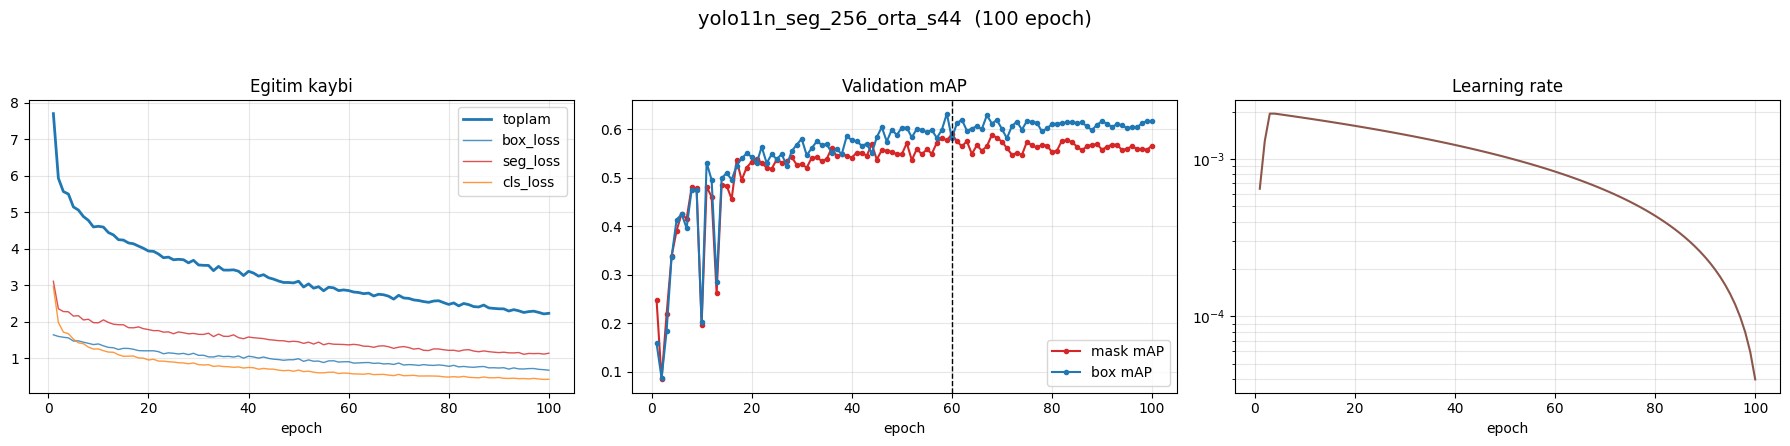

'/content/outputs/yolo11n_seg_256_orta_s44/yolo11n_seg_256_orta_s44_curves.png'

In [24]:
fig, ax = plt.subplots(1, 3, figsize=(18, 4.5))
a = ax[0]
a.plot(log.epoch, log.train_loss, lw=2, label='toplam')
for k, c in [('box_loss', 'tab:blue'), ('seg_loss', 'tab:red'), ('cls_loss', 'tab:orange')]:
    a.plot(log.epoch, log[k], lw=1, alpha=0.8, color=c, label=k)
a.set_title('Egitim kaybi'); a.set_xlabel('epoch'); a.legend(); a.grid(alpha=0.3)

a = ax[1]
a.plot(log.epoch, log.mask_mAP, marker='o', ms=3, color='tab:red', label='mask mAP')
a.plot(log.epoch, log.box_mAP, marker='o', ms=3, color='tab:blue', label='box mAP')
a.axvline(log.epoch[i], ls='--', lw=1, color='k')
a.set_title('Validation mAP'); a.set_xlabel('epoch'); a.legend(); a.grid(alpha=0.3)

a = ax[2]
a.plot(log.epoch, log.lr, color='tab:brown'); a.set_yscale('log')
a.set_title('Learning rate'); a.set_xlabel('epoch'); a.grid(alpha=0.3, which='both')

plt.suptitle(f'{MODEL_KEY}  ({len(log)} epoch)', fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.94])
plt.savefig(CURVES_PNG, dpi=150, bbox_inches='tight')
plt.show()
mirror_to_local(CURVES_PNG)

## Orijinal cozunurlukte Dice

`retina_masks=True` maskeyi girdi uzayinda degil orijinal goruntu boyutunda uretiyor.
Skor haritasi = her pikselde onu kaplayan instance'larin maksimum skoru; boylece bir
esikte esiklemek "skoru >= t olan instance'larin birlesimi"ne birebir esit oluyor ve
uc modelde de ayni esik taramasi calisiyor.

`conf` bilerek cok dusuk: esik taramasini biz yapiyoruz, Ultralytics'in kendi
filtresi taramanin alt ucunu kirpmasin.

In [25]:
import degerlendirme as dg

en_iyi = YOLO(f'{DRIVE_DIR}/best.pt')


def skor_haritasi(satir):
    yol = str(dg.yol_coz(satir.image_path))
    r = en_iyi.predict(yol, imgsz=GIRDI, conf=0.01, iou=0.7, retina_masks=True,
                       verbose=False, device=DEVICE)[0]
    sekil = (int(satir.height), int(satir.width))
    if r.masks is None or len(r.masks) == 0:
        return np.zeros(sekil, np.float32)
    return dg.instans_haritasi(r.masks.data.cpu().numpy(),
                               r.boxes.conf.cpu().numpy(), sekil)


gb_val = dg.goruntu_basina(skor_haritasi, 'val')
tablo_val = dg.esik_tablosu(gb_val)
ESIK = dg.en_iyi_esik(tablo_val)

print(tablo_val.to_string(index=False))
print('\nsecilen esik:', ESIK)
print('\nlezyon boyutu kirilimi:')
print(dg.boyut_kirilimi(gb_val, ESIK).to_string(index=False))

with pd.ExcelWriter(VAL_ESIK_XLSX) as w:
    tablo_val.to_excel(w, sheet_name='esik_taramasi', index=False)
    dg.boyut_kirilimi(gb_val, ESIK).to_excel(w, sheet_name='boyut', index=False)
    gb_val.to_excel(w, sheet_name='goruntu_basina', index=False)
mirror_to_local(VAL_ESIK_XLSX)

 esik  dice_tum  dice_lezyonlu  iou_lezyonlu  precision_lezyonlu  recall_lezyonlu  bos_dogru  bos_toplam
 0.01    0.6531         0.7475        0.6494              0.6967           0.8883          4          20
 0.02    0.6939         0.7759        0.6829              0.7354           0.8858          6          20
 0.05    0.7468         0.7774        0.6887              0.7442           0.8670         12          20
 0.10    0.7669         0.7913        0.7070              0.7613           0.8601         13          20
 0.15    0.7833         0.7902        0.7095              0.7613           0.8537         15          20
 0.20    0.7900         0.7879        0.7083              0.7564           0.8510         16          20
 0.30    0.8136         0.7956        0.7161              0.7653           0.8504         18          20
 0.40    0.7891         0.7660        0.6923              0.7357           0.8168         18          20
 0.50    0.7853         0.7614        0.6899           

'/content/outputs/yolo11n_seg_256_orta_s44/yolo11n_seg_256_orta_s44_val_esik.xlsx'

## Hizalama kontrolu

Tahmini kaydirinca Dice artiyor mu? Girdi hazirligi ile cikarim geri-olceklemesi
ayni piksel-merkezi konvansiyonunu kullanmiyorsa tahmin sistematik kayar ve zirve
(0, 0) disinda cikar.

RTMDet'te bu test pahali bir varsayimi cururtmustu (PLAN.md hata 9): teorik olarak
"dogru" olan on isleme aslinda hizalamayi bozuyordu.

Olcut zirvenin konumu **degil**, zirvenin merkeze gore kazanci. Tek piksellik bir
kaymada Dice zaten +-0.001 oynar; bunu "bozuk on isleme" saymak her kosuyu yanlis
isaretler. Karar `dg.hizalama_ozeti` ile veriliyor: kazanc 0.003'u asarsa bozuk.
Ayni fonksiyon SegFormer ve RTMDet notebooklarinda da kullaniliyor -- uc modelde
ayni esik.

In [26]:
kaydirma = dg.kaydirma_taramasi(skor_haritasi, 'val', esik=ESIK)
print(kaydirma.to_string())
print()
for k, v in dg.hizalama_ozeti(kaydirma).items():
    print(f'  {k}: {v}')

dx      -2      -1       0       1       2
dy                                        
-2  0.7878  0.7897  0.7910  0.7914  0.7908
-1  0.7911  0.7930  0.7943  0.7947  0.7941
 0  0.7923  0.7943  0.7956  0.7960  0.7954
 1  0.7919  0.7939  0.7952  0.7956  0.7952
 2  0.7898  0.7918  0.7931  0.7936  0.7931

  dy: 0
  dx: 1
  merkez: 0.7956
  en_iyi: 0.796
  kazanc: 0.0004
  kenar: False
  durum: hizalama tamam (kaydirma kazanci 0.0004 < 0.003)


## Test degerlendirmesi — esik val'den sabit

In [27]:
gb_test = dg.goruntu_basina(skor_haritasi, 'test', esikler=(ESIK,))
tablo_test = dg.esik_tablosu(gb_test)
print(tablo_test.to_string(index=False))
print('\nlezyon boyutu kirilimi:')
print(dg.boyut_kirilimi(gb_test, ESIK).to_string(index=False))

with pd.ExcelWriter(TEST_XLSX) as w:
    tablo_test.to_excel(w, sheet_name='ozet', index=False)
    dg.boyut_kirilimi(gb_test, ESIK).to_excel(w, sheet_name='boyut', index=False)
    gb_test.to_excel(w, sheet_name='goruntu_basina', index=False)
mirror_to_local(TEST_XLSX)

 esik  dice_tum  dice_lezyonlu  iou_lezyonlu  precision_lezyonlu  recall_lezyonlu  bos_dogru  bos_toplam
  0.3    0.7347         0.6926        0.6155              0.6938           0.7512         18          19

lezyon boyutu kirilimi:
   kova  n   dice    iou
    <80 16 0.7570 0.6698
 80-140 28 0.7463 0.6670
140-220 29 0.6551 0.5799
   >220 23 0.6296 0.5600


'/content/outputs/yolo11n_seg_256_orta_s44/yolo11n_seg_256_orta_s44_test_summary.xlsx'

## Sabit degerlendirme vakalari (uc modelde ortak)

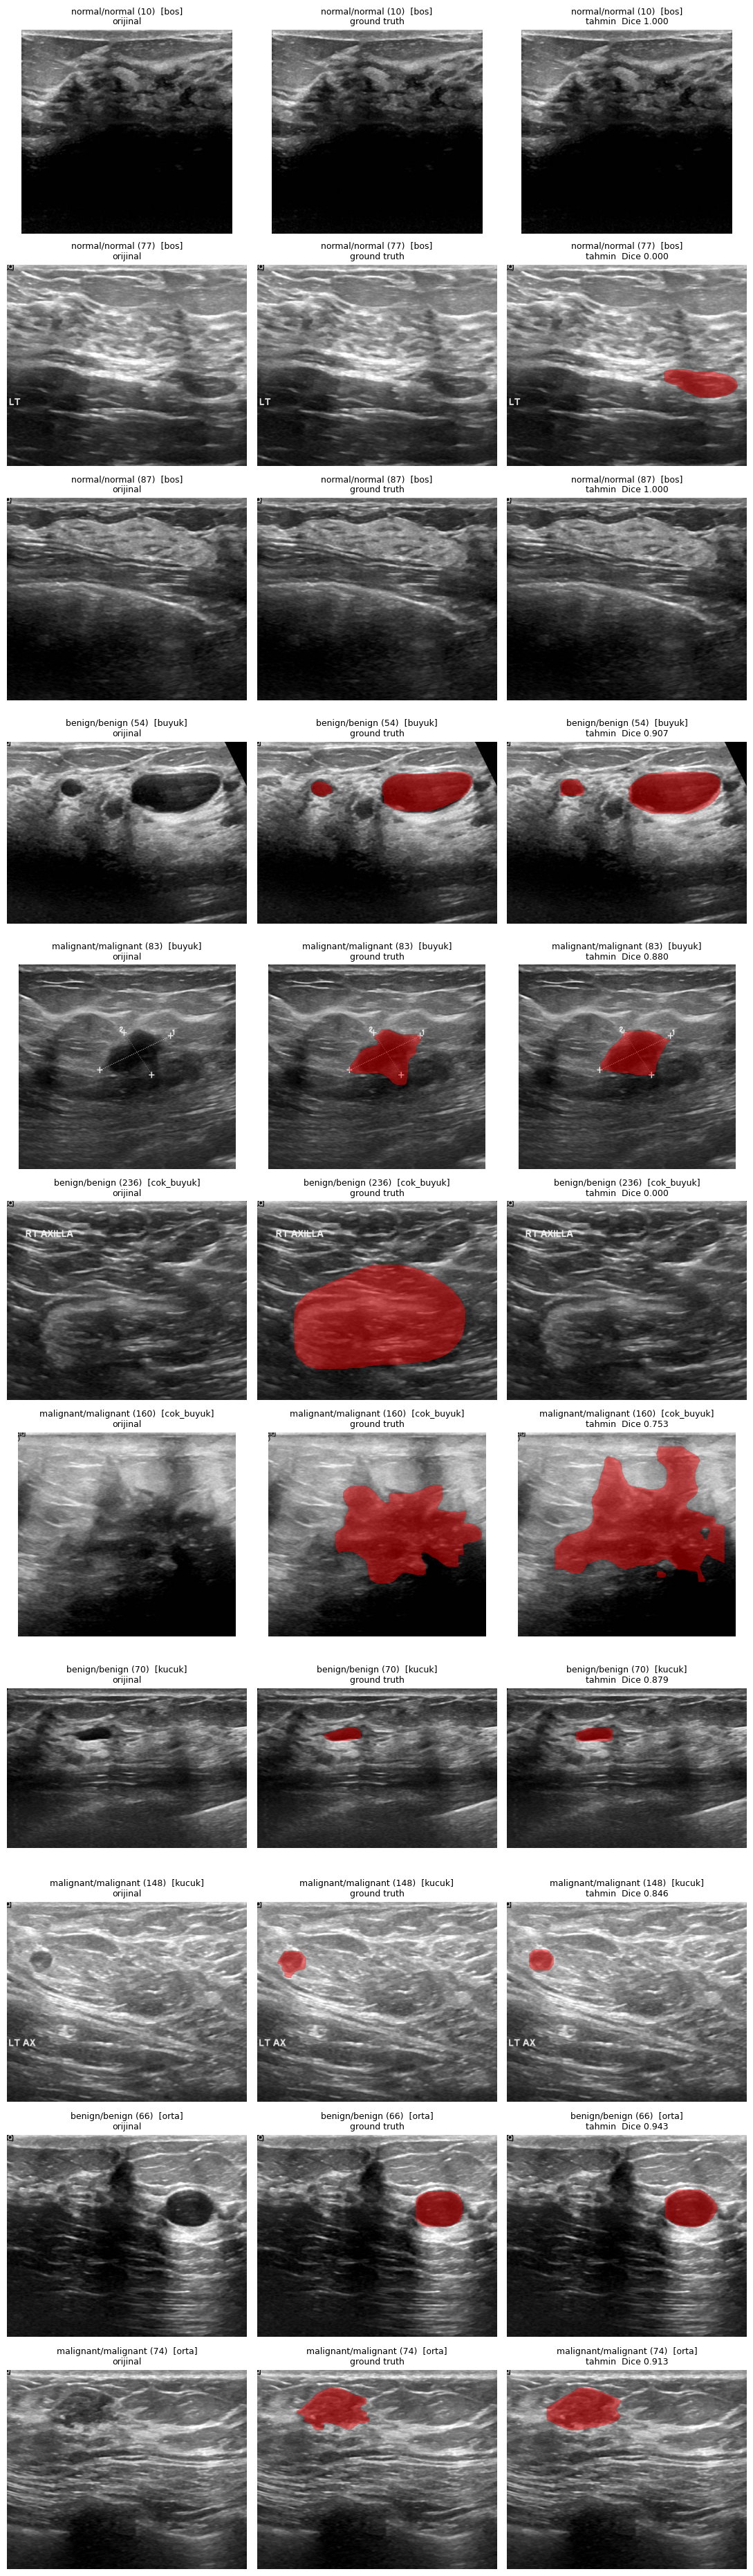

kaydedildi: /content/drive/MyDrive/real_time_segmentasyon/yolo11n_seg_256_orta_s44/yolo11n_seg_256_orta_s44_cases/yolo11n_seg_256_orta_s44_vakalar.png


In [28]:
vakalar = json.loads(Path(f'{PROJE}/ortak/eval_cases.json').read_text(encoding='utf-8'))['vakalar']
lut = {r.case_id: r for r in dg.manifest_oku().itertuples()}

fig, ax = plt.subplots(len(vakalar), 3, figsize=(11, 3.4 * len(vakalar)))
for i, v in enumerate(vakalar):
    r = lut[v['case_id']]
    img = dg.gri_oku(dg.yol_coz(r.image_path))
    gt = dg.gt_maskesi(r)
    pred = skor_haritasi(r) >= ESIK
    d = dg.metrikler(pred, gt)['dice']

    for j, (g, t) in enumerate([(img, 'orijinal'), (gt, 'ground truth'),
                                (pred, f'tahmin  Dice {d:.3f}')]):
        ax[i, j].imshow(img, cmap='gray')
        if j:
            ax[i, j].imshow(np.ma.masked_where(g == 0, g), cmap='autumn', alpha=0.45)
        ax[i, j].set_title(f"{v['case_id']}  [{v['kova']}]\n{t}", fontsize=9)
        ax[i, j].axis('off')

plt.tight_layout()
png = f'{CASES_DIR}/{MODEL_KEY}_vakalar.png'
plt.savefig(png, dpi=130, bbox_inches='tight')
plt.show()
print('kaydedildi:', png)